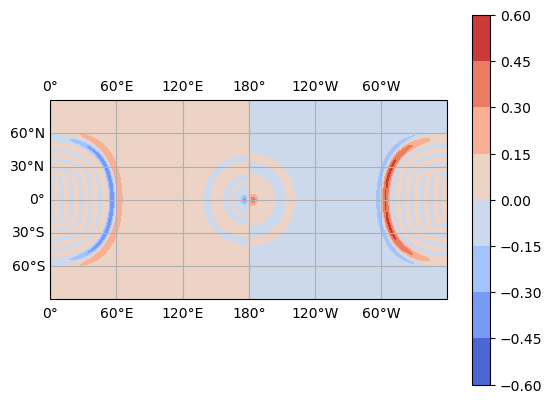

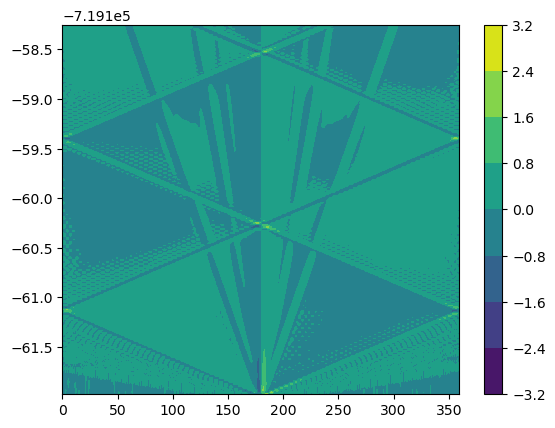

In [112]:
import os
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.dates import date2num


def LatLonPlot(MyAx, MyProj, field_DataArray, time_ind, lev_ind, MyCMAP):
    lats = field_DataArray.lat
    lons = field_DataArray.lon
 
    # select time
    field = field_DataArray[time_ind, lev_ind, :, :]

    CF = MyAx.contourf(lons, lats, field,
                     transform=ccrs.PlateCarree(), cmap=MyCMAP)
    plt.colorbar(CF, ax=MyAx)
    MyAx.gridlines(draw_labels=True)


def Hovmoller(MyAx, field_DataArray, lev_ind, lat_ind, MyCMAP):
    times_mdates = date2num(field_DataArray.time)
    lons = field_DataArray.lon
 
    # select time
    field = field_DataArray[:, lev_ind, lat_ind, :]

    CF = MyAx.contourf(lons, times_mdates, field, cmap=MyCMAP)
    plt.colorbar(CF, ax=MyAx)
    plt.show()


SCRATCHDIR = '/glade/derecho/scratch/nforcone'
RUNDIR = 'CAM_6_4_025_20240829_SEne30_L30_400m_fadiab_lamb/run'
FILENAME = 'CAM_6_4_025_20240829_SEne30_L30_400m_fadiab_lamb.cam.h0i.0001-01-01-01800.nc'
joined_path = os.path.join(SCRATCHDIR, RUNDIR, FILENAME)
joined_path
ds = xr.open_dataset(joined_path)

# plot U
projection = ccrs.PlateCarree(central_longitude=180)
U = ds.U  # (time:180, lev: 30, lat: 257, lon: 512)
time_index = 54
level_index = -1

plt.figure(1)
ax = plt.axes(projection=projection)

LatLonPlot(ax, projection, U, time_index, level_index, 'coolwarm')

# plot U Hovmoller
lat_index = 128

plt.figure(2)
ax2 = plt.axes()

Hovmoller(ax2, U, level_index, lat_index, 'viridis')